In [124]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
test_data = pd.read_csv('C:\\Users\\admin\\Downloads\\ab_test_data.csv')

In [126]:
print(test_data)

                                    user_id                   timestamp  \
0      7f6833e6-1141-4f20-b4b2-f1e31019b1fd  2023-07-04 04:40:55.848109   
1      e6a6e960-d3f3-4074-a516-ba1e609b211e  2023-07-06 00:26:45.486187   
2      4d3fbfa5-6847-410a-bac2-477f01d5f400  2023-07-10 20:24:33.639464   
3      361457d9-a044-48f7-981c-d67dc3861679  2023-07-20 07:04:49.957013   
4      285cd63d-7d03-427f-a062-1fa2dd2e77d6  2023-07-19 23:27:50.116680   
...                                     ...                         ...   
19993  6763ae9a-515c-473e-af00-0d9c4f6a5bc7  2023-07-06 03:27:37.041104   
19994  ac5600f2-4d16-4503-b115-f1a96728b6d1  2023-07-03 04:20:48.572143   
19995  5a8b2630-209b-4d83-b47f-0f3d9dd568a8  2023-07-23 16:23:49.211910   
19996  b572d68b-26ac-432b-9f88-83e0fdee4ca1  2023-07-03 18:26:20.880675   
19997  3d313adc-c8d6-43f2-8b4e-e267b194ff78  2023-07-19 13:15:37.562340   

      test_group  conversion  
0              a           0  
1              b           0  
2     

In [127]:
# Перевіримо кіль-ть учасників та % конверсій:
test_data.groupby('test_group').describe()

conversion                                             
                count      mean       std  min  25%  50%  75%  max
test_group                                                        
a             10013.0  0.061021  0.239380  0.0  0.0  0.0  0.0  1.0
b              9985.0  0.089034  0.284806  0.0  0.0  0.0  0.0  1.0

* завдяки функції describe знаємо, що умова рівності дисперсій не виконується, оскільки стандартні відхилення в групах різні
* mean = conversion (CR)

In [128]:
# Перевіримо суму та кіль-ть конверсій конверсій:
df_CR = test_data.groupby('test_group')['conversion'].agg(['count', 'sum', 'mean'])
df_CR.columns = ['Total_Users', 'Converted_Users', 'CR']
print(df_CR)

            Total_Users  Converted_Users        CR
test_group                                        
a                 10013              611  0.061021
b                  9985              889  0.089034


In [129]:
# Переглянемо тип колонок в нашому датафреймі
print(test_data.info())
print('-'*40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB
None
----------------------------------------


In [130]:
# Приведем стовпець timestamp у формат дати
test_data['timestamp'] = pd.to_datetime(test_data['timestamp'])

In [131]:
print(test_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     19998 non-null  object        
 1   timestamp   19998 non-null  datetime64[ns]
 2   test_group  19998 non-null  object        
 3   conversion  19998 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 625.1+ KB
None


In [132]:
#Створюю новий стовпець Дата
test_data['date'] = test_data['timestamp'].dt.date
print(test_data.head())

                                user_id                  timestamp test_group  \
0  7f6833e6-1141-4f20-b4b2-f1e31019b1fd 2023-07-04 04:40:55.848109          a   
1  e6a6e960-d3f3-4074-a516-ba1e609b211e 2023-07-06 00:26:45.486187          b   
2  4d3fbfa5-6847-410a-bac2-477f01d5f400 2023-07-10 20:24:33.639464          b   
3  361457d9-a044-48f7-981c-d67dc3861679 2023-07-20 07:04:49.957013          b   
4  285cd63d-7d03-427f-a062-1fa2dd2e77d6 2023-07-19 23:27:50.116680          b   

   conversion        date  
0           0  2023-07-04  
1           0  2023-07-06  
2           0  2023-07-10  
3           0  2023-07-20  
4           0  2023-07-19  


In [133]:
#Визначаємо дату початку та дату кінця тесту, а також тривалість тесту в днях.
start_date = test_data.date.min()
end_date = test_data.date.max()
print(f'Start test: {start_date}')
print(f'End test: {end_date}')
print(f'Duration test: {(end_date - start_date).days + 1} days')

Start test: 2023-07-03
End test: 2023-07-25
Duration test: 23 days


# Критерій Стʼюдента

* scipy.stats.ttest_ind — Тест (Тест Стʼюдента) для двох незалежних вибірок.

In [134]:
alpha = 0.05

statistic, pvalue = stats.ttest_ind(test_data[test_data['test_group'] == 'a']['conversion'],
                                    test_data[test_data['test_group'] == 'b']['conversion'], 
                                    alternative='less')

print(f't-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
#Різниця є статистично значущою, нульова гіпотеза відхиляється
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')
#Різниця незначна, нульову гіпотезу не можна відхилити

t-statistic: -7.53, p-value: 0.0
The difference is statistically significant, Null Hypothesis is rejected.


# Критерій Хі-квадрат, або Chi-squared 

In [135]:
alpha = 0.05

observed = pd.crosstab(test_data['test_group'].values, test_data['conversion'].values)
print(observed)
print('-'*30)
statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)

print(f't-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

col_0     0    1
row_0           
a      9402  611
b      9096  889
------------------------------
t-statistic: 56.14, p-value: 0.0
The difference is statistically significant, Null Hypothesis is rejected.


# Тест з перестановками в SciPy
Нульова гіпотеза: дані рандомно обрані з одного розподілу.

In [136]:
def statistic(x, y):
    return stats.ttest_ind(x, y).statistic

alpha = 0.05
    
x = test_data[test_data['test_group'] == 'a']['conversion']
y = test_data[test_data['test_group'] == 'b']['conversion']

results = stats.permutation_test((x, y), statistic, n_resamples=100)

print(f'statistic: {round(results.statistic, 2)}, p-value: {round(results.pvalue, 2)}')

if results.pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')


statistic: -7.53, p-value: 0.02
The difference is statistically significant, Null Hypothesis is rejected.


# Розрахунок приросту конверсій  групи 'b' проти контрольної групи 'a'

In [137]:
print(df_CR)
print('-'*50)
# Витягуємо значення CR для кожної групи
cr_a = df_CR.loc['a', 'CR']
cr_b = df_CR.loc['b', 'CR']
# Розраховуємо відносний приріст
CR = round((cr_b / cr_a - 1) * 100, 2)
print(f'Приріст конверсії в альтернативній групі проти контрольної становить {CR}%')

            Total_Users  Converted_Users        CR
test_group                                        
a                 10013              611  0.061021
b                  9985              889  0.089034
--------------------------------------------------
Приріст конверсії в альтернативній групі проти контрольної становить 45.91%


# Візуалізація отриманих результатів

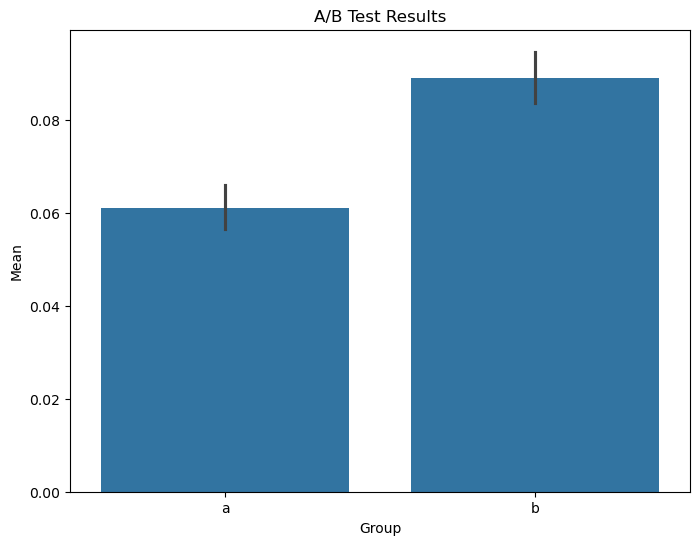

In [138]:
plt.figure(figsize=(8, 6))
sns.barplot(x=test_data['test_group'], 
            y=test_data['conversion'], 
            errorbar=('ci', 95)) # Confidence Intervals

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Mean')

plt.show()

* Аналіз графіка
1) Різниця висоти стовпців: Стовпець групи b помітно вищий за стовпець групи a (8.9% проти 6.1%).
2) Вусики (Error Bars): Це наші 95% довірчі інтервали. Оскільки ці "вусики" груп a та b зовсім не перетинаються по вертикалі, це наочний доказ того, що різниця між групами статистично значуща.

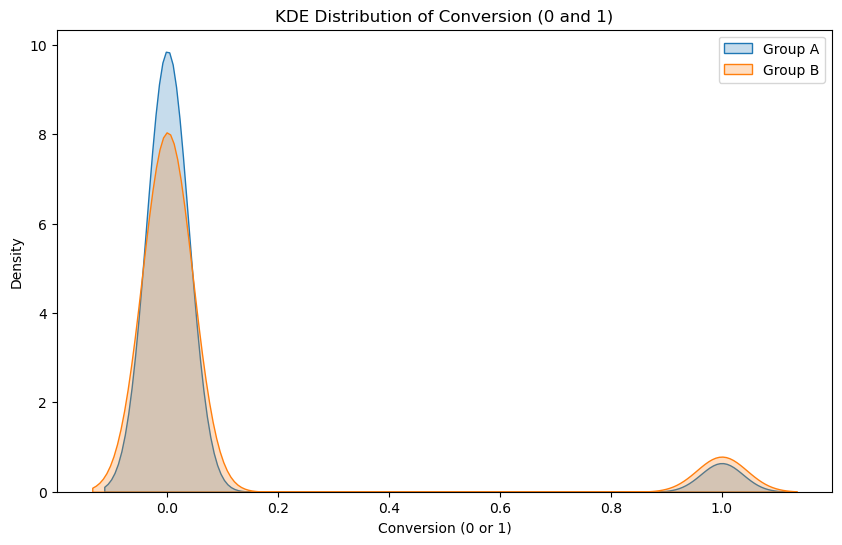

In [139]:
#Візуалізація розподілу

plt.figure(figsize=(10, 6))

sns.kdeplot(test_data[test_data['test_group'] == 'a']['conversion'], label='Group A', fill=True)
sns.kdeplot(test_data[test_data['test_group'] == 'b']['conversion'], label='Group B', fill=True)

plt.title('KDE Distribution of Conversion (0 and 1)')
plt.xlabel('Conversion (0 or 1)')
plt.ylabel('Density')
plt.legend()
plt.show()

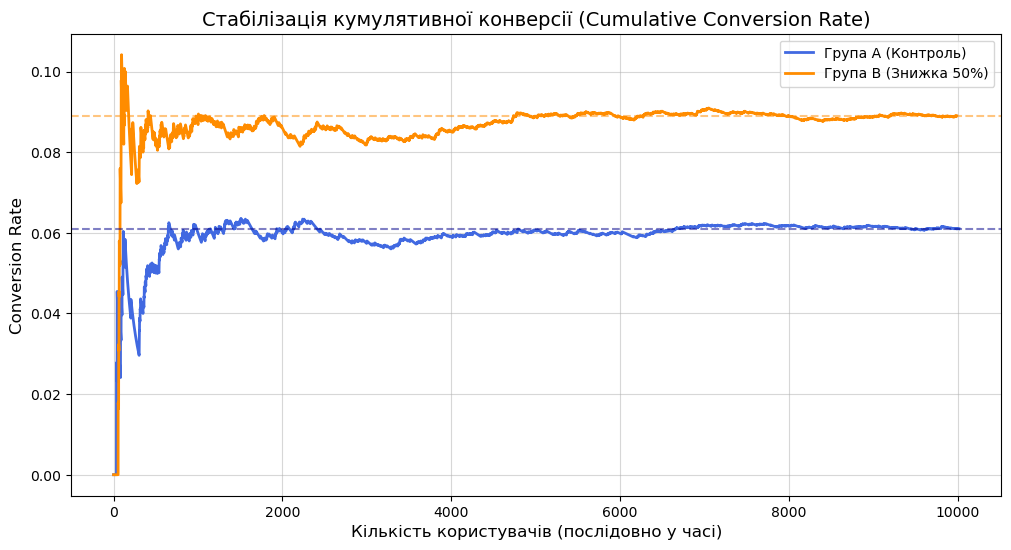

In [140]:
#Візуалізація зміни конверсії з часом

# 1. Сортуємо дані за датою та часом для коректного розрахунку кумулятивної метрики
# Використовуємо 'timestamp', бо він містить точний час, що дає плавнішу лінію
test_data = test_data.sort_values(by='timestamp')

# 2. Рахуємо кумулятивне середнє (expanding mean) для кожної групи
# Це показує, як змінювався CR від першого юзера до останнього
cum_a = test_data[test_data['test_group'] == 'a']['conversion'].expanding().mean().reset_index(drop=True)
cum_b = test_data[test_data['test_group'] == 'b']['conversion'].expanding().mean().reset_index(drop=True)

# 3. Візуалізація
plt.figure(figsize=(12, 6))
plt.plot(cum_a, label='Група A (Контроль)', color='royalblue', linewidth=2)
plt.plot(cum_b, label='Група B (Знижка 50%)', color='darkorange', linewidth=2)

# Додамо горизонтальні лінії фінальних значень для наочності
#Останнє значення (індекс -1) 
#це фінальна конверсія за весь період тесту (середнє по всіх юзерах груп).
plt.axhline(y=cum_a.iloc[-1], color='darkblue', linestyle='--', alpha=0.5)
plt.axhline(y=cum_b.iloc[-1], color='darkorange', linestyle='--', alpha=0.5)

plt.title('Стабілізація кумулятивної конверсії (Cumulative Conversion Rate)', fontsize=14)
plt.xlabel('Кількість користувачів (послідовно у часі)', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)

plt.grid(alpha=0.5)
plt.legend()
plt.show()

# Фінальні висновки для проекту:
1) На основі проведених розрахунків ми маємо повне право відхилити нульову гіпотезу.

2) Тест тривав 23 дні (з 03.07.2023 по 25.07.2023), що охоплює три повні тижневі цикли та дозволяє виключити вплив денної сезонності.

## Статистична значущість
* Для перевірки надійності результатів було використано три методи, кожен з яких підтвердив успішність тесту при рівні значущості alpha = 0.05 :
1) Критерій Стʼюдента (t-test): p-value = 0.0. Відмінність статистично значуща.
2) Критерій Хі-квадрат : Статистика 56.14, p-value = 0.0 Гіпотеза про відсутність зв'язку відхилена.
3) Тест з перестановками: p-value = 0.02 Навіть при непараметричній перевірці результат залишається значущим.

## Аналіз гіпотези та MDE
* Початкова ціль (Minimum Detectable Effect): Ми планували зафіксувати приріст конверсії щонайменше на 15%.
* Фактичний результат: Отриманий приріст у 45.9% значно перевищує очікуваний поріг.

## Бізнес-висновки та рекомендації
* Прийняття рішення: Рекомендується впровадити альтернативний дизайн (зі згадкою знижки 50%) для 100% нових користувачів. Психологічний ефект "ілюзорної знижки" виявився надзвичайно ефективним для даного продукту.
* Фінансовий ефект: Зростання конверсії з 6.1% до 8.9% при ціні підписки $4.99 дозволить суттєво збільшити дохід з кожного нового когортного потоку користувачів без додаткових витрат на маркетинг.

* Подальші кроки:
1) Моніторинг Retention: Оскільки знижка була ілюзорною, необхідно відстежити відсоток подовження підписки (churn rate) через місяць, щоб переконатися, що лояльність користувачів не знизилася.
2) Допоміжні метрики: Продовжити спостереження за ARPU, щоб підтвердити довгострокову вигоду від залучених користувачів.